In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('wine_data.csv', header=None, usecols=[0, 1, 2])

In [4]:
df.columns=['Class label', 'Alcohol', 'Malic acid']

In [5]:
df

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


# Implement the MinMaxScaling

## Calculate required values

In [12]:
alcohol_min = df['Alcohol'].min()
alcohol_max = df['Alcohol'].max()
malicacid_min = df['Malic acid'].min()
malicacid_max = df['Malic acid'].max()

In [15]:
df['alcohol_scaled'] = (df['Alcohol'] - alcohol_min)/(alcohol_max-alcohol_min)
df['malicacid_scaled'] = (df['Malic acid'] - malicacid_min)/(malicacid_max-malicacid_min)

In [16]:
df

,Class label,Alcohol,Malic acid,alcohol_scaled,malicacid_scaled
0,1,14.23,1.71,0.842105,0.191700
1,1,13.20,1.78,0.571053,0.205534
2,1,13.16,2.36,0.560526,0.320158
3,1,14.37,1.95,0.878947,0.239130
4,1,13.24,2.59,0.581579,0.365613
...,...,...,...,...,...
173,3,13.71,5.65,0.705263,0.970356
174,3,13.40,3.91,0.623684,0.626482
175,3,13.27,4.28,0.589474,0.699605
176,3,13.17,2.59,0.563158,0.365613


In [17]:
df.describe()

,Class label,Alcohol,Malic acid,alcohol_scaled,malicacid_scaled
count,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,0.518584,0.315484
std,0.775035,0.811827,1.117146,0.213639,0.220780
min,1.000000,11.030000,0.740000,0.000000,0.000000
25%,1.000000,12.362500,1.602500,0.350658,0.170455
50%,2.000000,13.050000,1.865000,0.531579,0.222332
75%,3.000000,13.677500,3.082500,0.696711,0.462945
max,3.000000,14.830000,5.800000,1.000000,1.000000


## The min max values came to 0 and 1 respectively.

<Axes: xlabel='alcohol_scaled', ylabel='malicacid_scaled'>

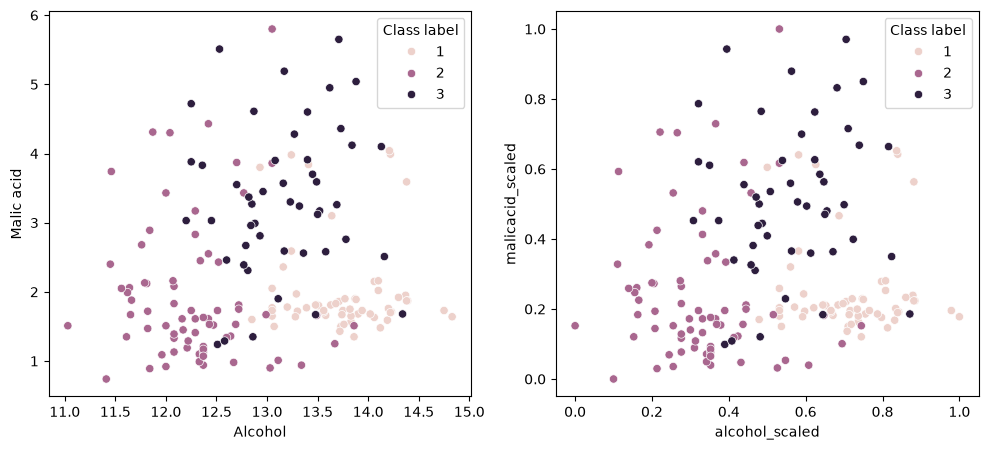

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=df, x='Alcohol', y='Malic acid', hue='Class label', ax=axes[0])
sns.scatterplot(data=df, x='alcohol_scaled', y='malicacid_scaled', hue='Class label', ax=axes[1])

No difference between both before and after normalization.

<Axes: xlabel='alcohol_scaled', ylabel='Density'>

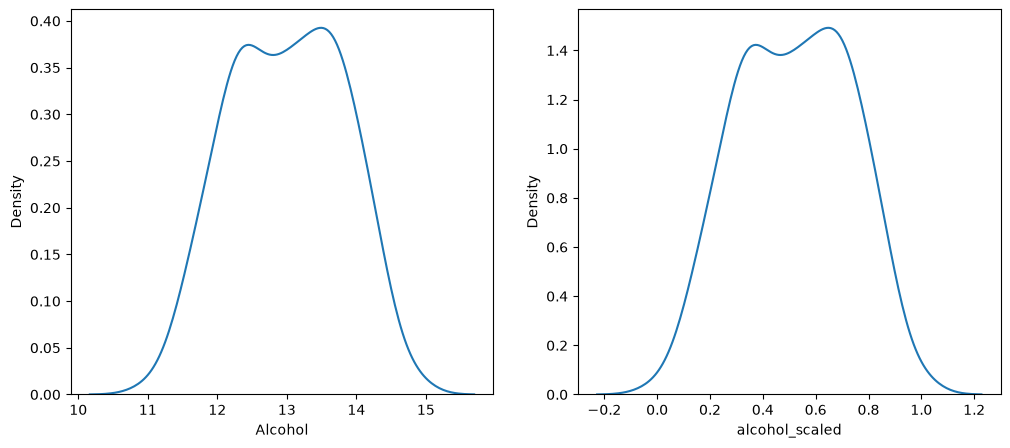

In [25]:
#lets see the distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(data=df, x='Alcohol', ax=axes[0])
sns.kdeplot(data=df, x='alcohol_scaled', ax=axes[1])

<Axes: xlabel='malicacid_scaled', ylabel='Density'>

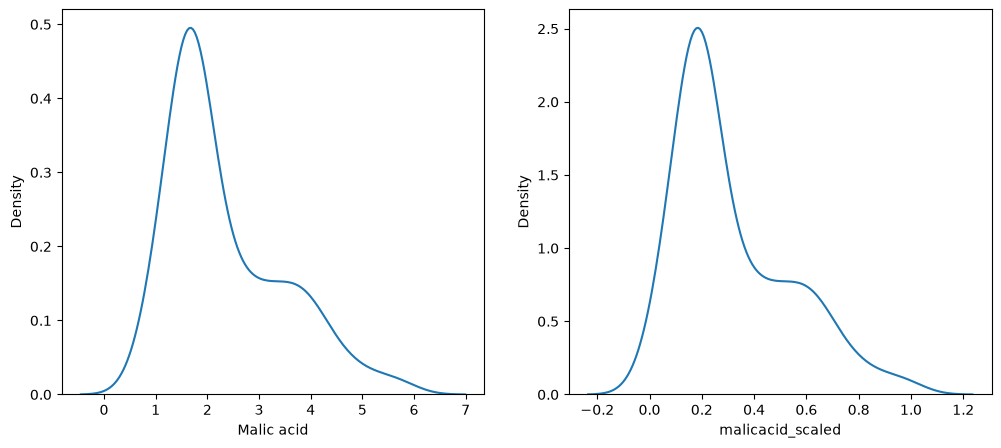

In [26]:
#lets see the distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(data=df, x='Malic acid', ax=axes[0])
sns.kdeplot(data=df, x='malicacid_scaled', ax=axes[1])

## The distribution is retained after normalization

# Implement the Mean Normalization

# Implement the MaxAbsScaling

# Implement the Robust scaling

# Using sklearn

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('Class label', axis=1),
                                                   df['Class label'],
                                                   test_size=0.3,
                                                   random_state=0)

In [9]:
X_train.shape

(124, 2)

In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
X_train.describe()

,Alcohol,Malic acid
count,124.000000,124.000000
mean,12.983065,2.383710
std,0.801340,1.136696
min,11.030000,0.890000
25%,12.362500,1.607500
50%,13.040000,1.885000
75%,13.640000,3.247500
max,14.750000,5.650000


In [14]:
X_train_scaled[:,0].min(), X_train_scaled[:,0].max()

(np.float64(0.0), np.float64(1.0))

In [15]:
X_train_scaled[:,1].min(), X_train_scaled[:,1].max()

(np.float64(0.0), np.float64(1.0))